In [83]:
import os 
from pathlib import Path

In [84]:
# make the dirs
Path('predictions').mkdir(exist_ok=True)
Path('uncertainty_maps').mkdir(exist_ok=True)

# move all the ones with uncertainty in the name to the uncertainty_maps folder
for file in os.listdir(base_dir):
    if file.endswith('.nii.gz'):
        if 'uncertainty' in file:
            os.rename(file, os.path.join('uncertainty_maps', file))
        else:
            os.rename(file, os.path.join('predictions', file))

NameError: name 'base_dir' is not defined

In [85]:
import os
import numpy as np
import json
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path

BASEDIR = '//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_2_mg/train_tta_predicted/'

label_files = [f for f in os.listdir(BASEDIR) if f.endswith('5.nii.gz')]

# import the nibabel things
os.chdir(BASEDIR)
Path('predictions').mkdir(exist_ok=True)
Path('uncertainty_maps').mkdir(exist_ok=True)

# move all the ones with uncertainty in the name to the uncertainty_maps folder
for file in os.listdir(BASEDIR):
    if file.endswith('.nii.gz'):
        if 'uncertainty' in file:
            os.rename(file, os.path.join('uncertainty_maps', file))
        else:
            os.rename(file, os.path.join('predictions', file))

In [88]:
import os
import numpy as np
import json
# BASEDIR = '//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_2_mg/'
# BASEDIR += 'train_tta_predicted/'
# # Now all paths are SHORT
# os.chdir(BASEDIR)
# UNCERTAINTY_MAPS_DIR = './uncertainty_maps_global_norm'
# # UNCERTAINTY_MAPS_DIR_RAW = './train_uncertainty_maps_raw'
# PREDICTED_LABELS_DIR = './predictions'
# SUMMARY_JSON_DIR     = './predictions/summary.json'
# TRUE_LABELS_DIR      = '/lab/B/BhattacharyaI/Public_Datasets/Autopet_III_nnunet_raw/Dataset888_AutoPet/labelsTr'
# SAVE_DIR             = '/lab/B/BhattacharyaI/Results/Biratal/Uncertainty_Examples/'

BASEDIR = '//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/'
BASEDIR += 'fold_10_ens_global_comb_train_results/'
# Now all paths are SHORT
os.chdir(BASEDIR)
UNCERTAINTY_MAPS_DIR = './train_uncertainty_maps'
# UNCERTAINTY_MAPS_DIR_RAW = './train_uncertainty_maps_raw'
PREDICTED_LABELS_DIR = './train_predictions'
SUMMARY_JSON_DIR     = './train_predictions/summary.json'
TRUE_LABELS_DIR      = '/lab/B/BhattacharyaI/Public_Datasets/Autopet_III_nnunet_raw/Dataset888_AutoPet/labelsTr'
SAVE_DIR             = '/lab/B/BhattacharyaI/Results/Biratal/Uncertainty_Examples'


# Verify
print("UNCERTAINTY_MAPS_DIR exists:", os.path.exists(UNCERTAINTY_MAPS_DIR))
print("PREDICTED_LABELS_DIR exists:", os.path.exists(PREDICTED_LABELS_DIR))
print("SUMMARY_JSON_DIR exists:    ", os.path.exists(SUMMARY_JSON_DIR))
print("TRUE_LABELS_DIR exists:     ", os.path.exists(TRUE_LABELS_DIR))
print("SAVE_DIR exists:            ", os.path.exists(SAVE_DIR))

# Load summary JSON
with open(SUMMARY_JSON_DIR, 'r') as f:
    summary_json = json.load(f)

per_cases = summary_json['metric_per_case']

# Find uncertainty map files
X = "_uncertainty"
files_with_prefix = [
    f for f in os.listdir(UNCERTAINTY_MAPS_DIR)
    if f.endswith(f'{X}.nii.gz')
]
file_names_in_true = [f.replace(X, '').strip() for f in files_with_prefix]

file_dices = []
    
print("\nFiles found:", len(files_with_prefix))
print(files_with_prefix[:5])
print(file_names_in_true[:5])


# pickle_file_path = os.path.join(UNCERTAINTY_MAPS_DIR, 'global_uncertainty_stats.pkl')
# global_stats = np.load(pickle_file_path, allow_pickle=True)

UNCERTAINTY_MAPS_DIR exists: True
PREDICTED_LABELS_DIR exists: True
SUMMARY_JSON_DIR exists:     True
TRUE_LABELS_DIR exists:      True
SAVE_DIR exists:             True

Files found: 2820
['fdg_d626611daf_04-03-2003-NA-PET-CT Ganzkoerper  primaer mit KM-63001_epistemic_uncertainty.nii.gz', 'fdg_86e54ea60a_03-18-2002-NA-PET-CT Ganzkoerper  primaer mit KM-34788_aleatoric_uncertainty.nii.gz', 'fdg_442a09f90e_03-16-2002-NA-PET-CT Ganzkoerper  primaer mit KM-24290_aleatoric_uncertainty.nii.gz', 'fdg_527c5afc5d_07-18-2003-NA-PET-CT Ganzkoerper  primaer mit KM-02474_aleatoric_uncertainty.nii.gz', 'psma_838c9340e85ca431_2020-05-23_total_uncertainty.nii.gz']
['fdg_d626611daf_04-03-2003-NA-PET-CT Ganzkoerper  primaer mit KM-63001_epistemic.nii.gz', 'fdg_86e54ea60a_03-18-2002-NA-PET-CT Ganzkoerper  primaer mit KM-34788_aleatoric.nii.gz', 'fdg_442a09f90e_03-16-2002-NA-PET-CT Ganzkoerper  primaer mit KM-24290_aleatoric.nii.gz', 'fdg_527c5afc5d_07-18-2003-NA-PET-CT Ganzkoerper  primaer mit KM-02474

In [81]:
# import os
# import numpy as np
# import json
# import nibabel as nib
# from scipy import ndimage
# import matplotlib.pyplot as plt
# from tqdm import tqdm

# BASEDIR = '//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_2_mg/'
# BASEDIR += 'train_tta_predicted/'
# os.chdir(BASEDIR)

# UNCERTAINTY_MAPS_DIR = './uncertainty_maps_global_norm'
# PREDICTED_LABELS_DIR = './predictions'
# SUMMARY_JSON_DIR     = './predictions/summary.json'
# TRUE_LABELS_DIR      = '/lab/B/BhattacharyaI/Public_Datasets/Autopet_III_nnunet_raw/Dataset888_AutoPet/labelsTr'
# SAVE_DIR             = '/lab/B/BhattacharyaI/Results/Biratal/Uncertainty_Examples/'

# # ─────────────────────────────────────────────────────────────────────────────
# # HELPER FUNCTIONS
# # ─────────────────────────────────────────────────────────────────────────────

# def load_nifti(path):
#     """Load a NIfTI file and return numpy array."""
#     return nib.load(path).get_fdata()


# def get_connected_components(binary_mask):
#     """
#     Label connected components in a binary mask.
#     Returns:
#         labeled_array : ndarray with each region labeled with unique int
#         num_features  : number of regions found
#     """
#     struct = ndimage.generate_binary_structure(3, 2)  # 26-connectivity in 3D
#     labeled_array, num_features = ndimage.label(binary_mask, structure=struct)
#     return labeled_array, num_features


# def compute_region_uncertainty(uncertainty_map, region_mask):
#     """
#     Compute the mean uncertainty within a region (Equation 3 in paper).
    
#     Args:
#         uncertainty_map : 3D numpy array of voxel-level uncertainties
#         region_mask     : boolean mask for the region of interest
#     Returns:
#         mean uncertainty scalar
#     """
#     voxels = uncertainty_map[region_mask > 0]
#     if len(voxels) == 0:
#         return 0.0
#     return np.mean(voxels)


# def compute_iou(mask_a, mask_b):
#     """Compute IoU between two binary masks."""
#     intersection = np.logical_and(mask_a, mask_b).sum()
#     union        = np.logical_or(mask_a, mask_b).sum()
#     if union == 0:
#         return 0.0
#     return intersection / union


# def match_regions(pred_labeled, gt_labeled, num_pred, num_gt, iou_threshold=0.1):
#     """
#     Match predicted regions to ground-truth regions using IoU.
    
#     Args:
#         pred_labeled   : labeled array of predicted regions
#         gt_labeled     : labeled array of ground-truth regions
#         num_pred       : number of predicted regions
#         num_gt         : number of ground-truth regions
#         iou_threshold  : minimum IoU to consider a match
    
#     Returns:
#         matched_gt     : set of GT region labels that were matched
#         matched_pred   : set of Pred region labels that were matched
#         tp_pred_ids    : list of matched predicted region IDs (TPs)
#         fn_gt_ids      : list of unmatched GT region IDs (FNs)
#     """
#     matched_gt   = set()
#     matched_pred = set()

#     # Build IoU matrix
#     for pred_id in range(1, num_pred + 1):
#         pred_mask = (pred_labeled == pred_id)
#         best_iou  = 0.0
#         best_gt   = None

#         for gt_id in range(1, num_gt + 1):
#             gt_mask = (gt_labeled == gt_id)
#             iou     = compute_iou(pred_mask, gt_mask)
#             if iou > best_iou:
#                 best_iou = iou
#                 best_gt  = gt_id

#         if best_iou >= iou_threshold and best_gt is not None:
#             matched_gt.add(best_gt)
#             matched_pred.add(pred_id)

#     # TP predicted regions = those that were matched
#     tp_pred_ids = list(matched_pred)

#     # FN gt regions = those that were NOT matched
#     fn_gt_ids = [gt_id for gt_id in range(1, num_gt + 1)
#                  if gt_id not in matched_gt]

#     return matched_gt, matched_pred, tp_pred_ids, fn_gt_ids


# # ─────────────────────────────────────────────────────────────────────────────
# # CORE ANALYSIS FUNCTION (per image)
# # ─────────────────────────────────────────────────────────────────────────────

# def compute_fn_recall_per_image(uncertainty_map, pred_mask, gt_mask,
#                                 threshold_factors):
#     """
#     For a single image:
#       1. Find TP predicted regions and FN ground-truth regions
#       2. Compute regional uncertainty for each
#       3. Compute FN recall rate across threshold factors
    
#     Args:
#         uncertainty_map     : 3D uncertainty array
#         pred_mask           : 3D binary predicted segmentation
#         gt_mask             : 3D binary ground-truth segmentation
#         threshold_factors   : array of factors (e.g., linspace(1.0, 0.05, 20))
    
#     Returns:
#         fn_recall_rates     : array of recall rates, one per threshold factor
#         median_tp_unc       : median TP uncertainty (reference)
#         fn_uncertainties    : list of FN region uncertainty values
#         num_fn              : number of FN regions
#     """

#     # ── Step 1: Connected components ─────────────────────────────────────────
#     pred_labeled, num_pred = get_connected_components(pred_mask > 0)
#     gt_labeled,   num_gt   = get_connected_components(gt_mask > 0)

#     # Edge case: no GT regions → nothing to evaluate
#     if num_gt == 0:
#         return np.zeros(len(threshold_factors)), np.nan, [], 0

#     # Edge case: no predicted regions → all GT are FN
#     if num_pred == 0:
#         fn_gt_ids   = list(range(1, num_gt + 1))
#         tp_pred_ids = []
#     else:
#         _, _, tp_pred_ids, fn_gt_ids = match_regions(
#             pred_labeled, gt_labeled, num_pred, num_gt
#         )

#     # ── Step 2: Compute TP regional uncertainties ─────────────────────────────
#     tp_uncertainties = []
#     for pred_id in tp_pred_ids:
#         region_mask = (pred_labeled == pred_id)
#         unc         = compute_region_uncertainty(uncertainty_map, region_mask)
#         tp_uncertainties.append(unc)

#     # Median TP uncertainty as reference
#     if len(tp_uncertainties) > 0:
#         median_tp_unc = np.median(tp_uncertainties)
#     else:
#         # No TPs — fallback to global median of predicted mask
#         # (or could skip this image)
#         median_tp_unc = np.median(uncertainty_map[pred_mask > 0]) \
#                         if pred_mask.sum() > 0 else np.nan

#     # ── Step 3: Compute FN regional uncertainties ────────────────────────────
#     fn_uncertainties = []
#     for gt_id in fn_gt_ids:
#         # Use GT mask as spatial localization (model never predicted here)
#         region_mask = (gt_labeled == gt_id)
#         unc         = compute_region_uncertainty(uncertainty_map, region_mask)
#         fn_uncertainties.append(unc)

#     num_fn = len(fn_gt_ids)

#     # ── Step 4: Compute FN recall rate at each threshold ─────────────────────
#     fn_recall_rates = np.zeros(len(threshold_factors))

#     if num_fn == 0 or np.isnan(median_tp_unc):
#         return fn_recall_rates, median_tp_unc, fn_uncertainties, num_fn

#     fn_uncertainties_arr = np.array(fn_uncertainties)

#     for i, factor in enumerate(threshold_factors):
#         threshold = factor * median_tp_unc
#         # FN regions with uncertainty >= threshold
#         num_recovered      = np.sum(fn_uncertainties_arr >= threshold)
#         fn_recall_rates[i] = num_recovered / num_fn

#     return fn_recall_rates, median_tp_unc, fn_uncertainties, num_fn


# # ─────────────────────────────────────────────────────────────────────────────
# # MAIN LOOP
# # ─────────────────────────────────────────────────────────────────────────────

# def run_fn_recovery_analysis(files_with_prefix, file_names_in_true,
#                               threshold_factors=None):
#     """
#     Run FN recovery analysis across all images.
    
#     Args:
#         files_with_prefix   : list of uncertainty map filenames
#         file_names_in_true  : corresponding prediction/GT filenames
#         threshold_factors   : array of threshold factors to evaluate
    
#     Returns:
#         results_dict : dict with per-image and aggregate results
#     """

#     if threshold_factors is None:
#         # Linearly spaced from 100% to 5% of median TP uncertainty
#         threshold_factors = np.linspace(1.0, 0.05, 40)

#     all_fn_recall_rates = []   # shape: (num_valid_images, num_thresholds)
#     all_median_tp_uncs  = []
#     all_fn_uncertainties = []
#     all_num_fns         = []
#     skipped_cases       = []

#     for unc_file, true_file in tqdm(
#         zip(files_with_prefix, file_names_in_true),
#         total=len(files_with_prefix),
#         desc="Processing cases"
#     ):
#         # ── Build file paths ─────────────────────────────────────────────────
#         unc_path  = os.path.join(UNCERTAINTY_MAPS_DIR, unc_file)
#         pred_path = os.path.join(PREDICTED_LABELS_DIR, true_file)
#         gt_path   = os.path.join(TRUE_LABELS_DIR,      true_file)

#         # Check all files exist
#         if not all(os.path.exists(p) for p in [unc_path, pred_path, gt_path]):
#             print(f"  [SKIP] Missing files for: {true_file}")
#             skipped_cases.append(true_file)
#             continue

#         # ── Load arrays ──────────────────────────────────────────────────────
#         uncertainty_map = load_nifti(unc_path)
#         pred_mask       = load_nifti(pred_path)
#         gt_mask         = load_nifti(gt_path)

#         # Binarize (in case of multi-class)
#         pred_mask = (pred_mask > 0).astype(np.uint8)
#         gt_mask   = (gt_mask   > 0).astype(np.uint8)

#         # ── Compute FN recall ─────────────────────────────────────────────────
#         fn_recall_rates, median_tp_unc, fn_uncs, num_fn = \
#             compute_fn_recall_per_image(
#                 uncertainty_map, pred_mask, gt_mask, threshold_factors
#             )

#         # Skip images with no FN regions (nothing to recover)
#         if num_fn == 0:
#             continue

#         # Skip images where median TP uncertainty is undefined
#         if np.isnan(median_tp_unc):
#             skipped_cases.append(true_file)
#             continue

#         all_fn_recall_rates.append(fn_recall_rates)
#         all_median_tp_uncs.append(median_tp_unc)
#         all_fn_uncertainties.extend(fn_uncs)
#         all_num_fns.append(num_fn)

#     # ── Aggregate ─────────────────────────────────────────────────────────────
#     all_fn_recall_rates = np.array(all_fn_recall_rates)   # (N_images, N_thresholds)
#     mean_fn_recall      = np.mean(all_fn_recall_rates, axis=0)  # (N_thresholds,)

#     # Find recall at specific threshold factors
#     idx_05  = np.argmin(np.abs(threshold_factors - 0.5))
#     idx_01  = np.argmin(np.abs(threshold_factors - 0.1))

#     recall_at_05 = mean_fn_recall[idx_05]
#     recall_at_01 = mean_fn_recall[idx_01]

#     print(f"\n{'='*50}")
#     print(f"  Total images processed : {len(all_fn_recall_rates)}")
#     print(f"  Total FN regions found : {sum(all_num_fns)}")
#     print(f"  Skipped cases          : {len(skipped_cases)}")
#     print(f"  FN Recall @ factor=0.5 : {recall_at_05:.4f}")
#     print(f"  FN Recall @ factor=0.1 : {recall_at_01:.4f}")
#     print(f"{'='*50}\n")

#     results_dict = {
#         'threshold_factors'   : threshold_factors,
#         'mean_fn_recall'      : mean_fn_recall,
#         'all_fn_recall_rates' : all_fn_recall_rates,
#         'recall_at_05'        : recall_at_05,
#         'recall_at_01'        : recall_at_01,
#         'all_median_tp_uncs'  : all_median_tp_uncs,
#         'all_fn_uncertainties': all_fn_uncertainties,
#         'num_fns_per_image'   : all_num_fns,
#         'skipped_cases'       : skipped_cases,
#     }

#     return results_dict


# # ─────────────────────────────────────────────────────────────────────────────
# # PLOTTING
# # ─────────────────────────────────────────────────────────────────────────────

# def plot_fn_recall_curve(results_dict, save_path=None, label='Uncertainty Measure'):
#     """
#     Plot mean FN recall rate as a function of threshold factor.
    
#     Args:
#         results_dict : output from run_fn_recovery_analysis()
#         save_path    : if provided, saves figure to this path
#         label        : legend label for the curve
#     """
#     factors    = results_dict['threshold_factors']
#     mean_recall = results_dict['mean_fn_recall']

#     fig, ax = plt.subplots(figsize=(8, 5))

#     ax.plot(factors, mean_recall, 'b-o', markersize=4, label=label)

#     # Mark the two key thresholds
#     ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.7,
#                label=f"Factor=0.5  (Recall={results_dict['recall_at_05']:.3f})")
#     ax.axvline(x=0.1, color='red',    linestyle='--', alpha=0.7,
#                label=f"Factor=0.1  (Recall={results_dict['recall_at_01']:.3f})")

#     ax.set_xlabel('Threshold Factor\n(× Median TP Uncertainty)', fontsize=13)
#     ax.set_ylabel('Mean FN Recall Rate',                         fontsize=13)
#     ax.set_title('FN Region Recovery via Uncertainty Thresholding',fontsize=14)
#     ax.set_xlim([0, 1.05])
#     ax.set_ylim([0, 1.05])
#     ax.legend(fontsize=11)
#     ax.grid(True, alpha=0.3)
#     ax.invert_xaxis()   # Higher threshold (stricter) on the left

#     plt.tight_layout()

#     if save_path:
#         plt.savefig(save_path, dpi=150, bbox_inches='tight')
#         print(f"  Plot saved to: {save_path}")

#     plt.show()


# # ─────────────────────────────────────────────────────────────────────────────
# # RUN
# # ─────────────────────────────────────────────────────────────────────────────

# if __name__ == '__main__':

#     # Define threshold factors: 100% → 5% of median TP uncertainty
#     threshold_factors = np.linspace(1.0, 0.05, 40)

#     # Run analysis
#     results = run_fn_recovery_analysis(
#         files_with_prefix  = files_with_prefix[:5],
#         file_names_in_true = file_names_in_true[:5],
#         threshold_factors  = threshold_factors
#     )

#     # Plot
#     plot_fn_recall_curve(
#         results,
#         save_path=os.path.join(SAVE_DIR, 'fn_recall_curve.png'),
#         label='Global Norm Uncertainty'
#     )

#     # Save results
#     np.save(os.path.join(SAVE_DIR, 'fn_recall_results.npy'), results)
#     print("Results saved.")

In [50]:
import nibabel as nib

def get_uncertainty_map(case, unc_dir=UNCERTAINTY_MAPS_DIR, binned = False): 
    uncertainty_map_path = os.path.join(unc_dir, case)
    uncertainty_map = nib.load((uncertainty_map_path)).get_fdata()
    if binned:
        uncertainty_map = np.digitize(uncertainty_map, bins=20)
    return uncertainty_map

def get_predicted_label(case, pred_dir=PREDICTED_LABELS_DIR):
    predicted_label_path = os.path.join(pred_dir, case.replace('_total_uncertainty', ''))
    predicted_label = nib.load((predicted_label_path)).get_fdata()
    return predicted_label

def get_dice_for_case(case, per_cases=per_cases):
    for item in per_cases:
        if case.replace('_total_uncertainty', '') in item['prediction_file']:
            return item['metrics']['1']['Dice']
    return None




In [53]:
import numpy as np
import tqdm 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def process_uncertainty_map(uncertainty_map, filename, predicted_label=None, bin_size=0.05, max_val=1.0):
    """
    Takes an uncertainty map, bins it, and returns statistics.
    
    Parameters:
    -----------
    uncertainty_map : np.ndarray
        The uncertainty map
    filename : str
        Name of the file
    predicted_label : np.ndarray, optional
        Binary mask of predicted pixels (predicted > 0). If provided, 
        calculates uncertainty statistics for predicted vs non-predicted regions.
    bin_size : float
        Size of bins for histogram
    max_val : float
        Maximum value for histogram
    
    Returns:
    --------
    tuple : (binned_df, summary_df)
        - binned_df: DataFrame with histogram bins
        - summary_df: DataFrame with aggregate statistics
    """
    values = uncertainty_map.flatten()
    bin_edges = np.arange(0, max_val + bin_size, bin_size)
    counts, edges = np.histogram(values, bins=bin_edges)
    bin_labels = [f"{edges[i]:.2f}-{edges[i+1]:.2f}" for i in range(len(edges)-1)]    
    
    binned_df = pd.DataFrame({
        'bin': bin_labels,
        'count': counts,
        'filename': filename
    })
    
    # Calculate summary statistics
    summary_stats = {
        'filename': filename,
        'average_uncertainty': float(np.mean(values)),
        'average_uncertainty_above_0': float(np.mean(values[values > 0])) if np.any(values > 0) else np.nan,
    }
    
    # Add predicted/non-predicted statistics if mask is provided
    if predicted_label is not None:
        predicted_mask = predicted_label > 0
        uncertainty_predicted = values[predicted_mask.flatten()]
        uncertainty_non_predicted = values[~predicted_mask.flatten()]
        
        summary_stats['average_uncertainty_predicted'] = float(np.mean(uncertainty_predicted)) if uncertainty_predicted.size > 0 else np.nan
        summary_stats['average_uncertainty_non_predicted'] = float(np.mean(uncertainty_non_predicted)) if uncertainty_non_predicted.size > 0 else np.nan
    else:
        summary_stats['average_uncertainty_predicted'] = np.nan
        summary_stats['average_uncertainty_non_predicted'] = np.nan
    
    summary_df = pd.DataFrame([summary_stats])
    
    return binned_df, summary_df

    
# Usage - loop over your files
dfs = []
summary_dfs = []
for filepath in tqdm.tqdm(file_names_in_true):  # Process first 10a files as an example
    uncertainty_map = get_uncertainty_map(filepath.replace('.nii.gz', '_uncertainty_uncertainty.nii.gz'), UNCERTAINTY_MAPS_DIR)
    predicted_map = get_predicted_label(filepath, PREDICTED_LABELS_DIR)
    dice_for_case = get_dice_for_case(filepath, per_cases)
    
    filename = os.path.basename(filepath)
    binned_df, summary_df = process_uncertainty_map(uncertainty_map, filename, predicted_label=predicted_map)
    # add the dice
    summary_df['dice'] = dice_for_case
    binned_df['dice'] = dice_for_case
    dfs.append(binned_df)
    summary_dfs.append(summary_df)

combined_df = pd.concat(dfs, ignore_index=True)
combined_summary_df = pd.concat(summary_dfs, ignore_index=True)


100%|██████████| 940/940 [21:32<00:00,  1.38s/it]


100%|██████████| 2820/2820 [15:55<00:00,  2.95it/s]


CSV saved to: /lab/B/BhattacharyaI/Results/Biratal/Uncertainty_Examples\high_uncertainty_voxel_counts.csv
          threshold  num_high_unc_voxels  total_voxels  percent_high_unc
count  9.400000e+02           940.000000  9.400000e+02        940.000000
mean   6.500000e-01          2642.073404  4.125177e+07          0.011011
std    1.110814e-16          5403.365346  2.395998e+07          0.028039
min    6.500000e-01             0.000000  3.810240e+06          0.000000
25%    6.500000e-01            54.750000  1.723597e+07          0.000141
50%    6.500000e-01           331.500000  4.544000e+07          0.000982
75%    6.500000e-01          2357.750000  5.216000e+07          0.007303
max    6.500000e-01         36064.000000  1.057600e+08          0.251523
Plot saved to: /lab/B/BhattacharyaI/Results/Biratal/Uncertainty_Examples\high_uncertainty_voxel_distribution.png


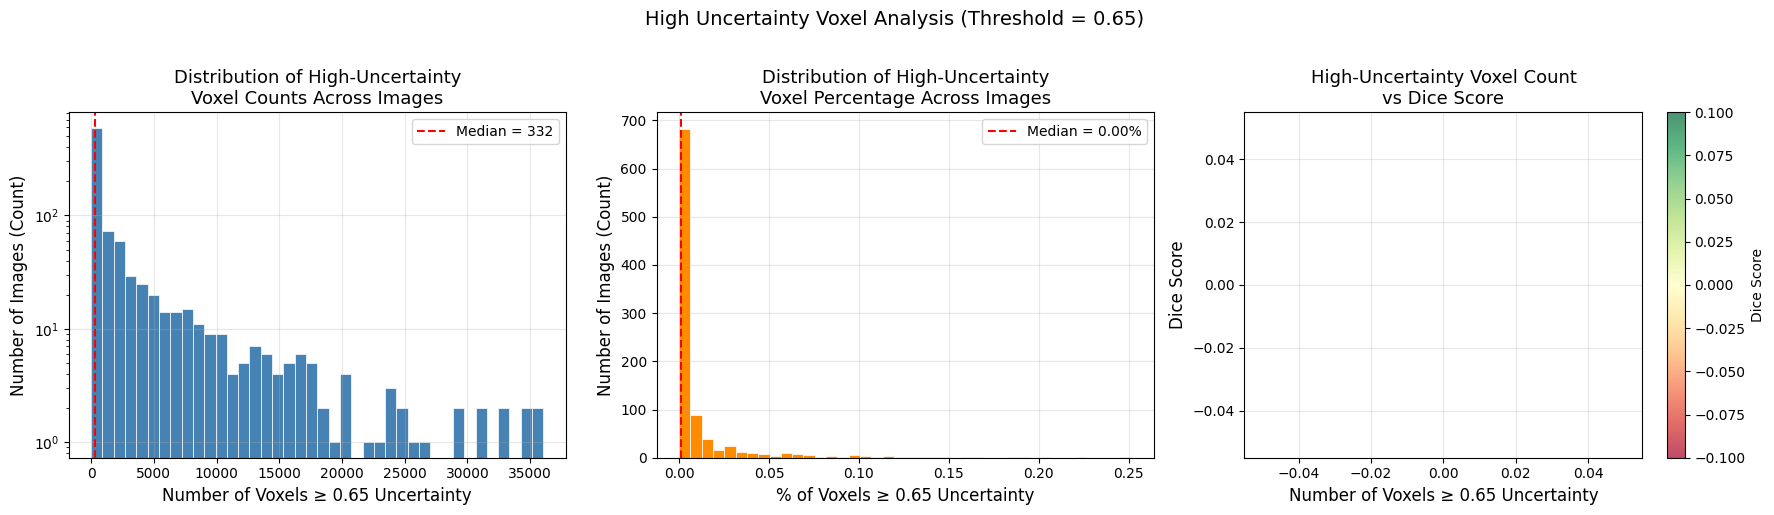


  Total images processed          : 940
  Images with ANY voxels ≥ 0.65   : 867
  Images with ZERO voxels ≥ 0.65  : 73
  Median high-unc voxel count     : 332
  Max high-unc voxel count        : 36064
  Mean % high-unc voxels          : 0.011%


In [97]:
def process_high_uncertainty_voxels(uncertainty_map, filename, threshold=0.65):
    """
    Counts voxels above a given uncertainty threshold for a single image.
    
    Parameters:
    -----------
    uncertainty_map : np.ndarray
        The uncertainty map
    filename : str
        Name of the file
    threshold : float
        Uncertainty threshold (default=0.65)
    
    Returns:
    --------
    summary_df : DataFrame with voxel count above threshold
    """
    values = uncertainty_map.flatten()
    high_unc_voxels = np.sum(values >= threshold)
    
    summary_df = pd.DataFrame([{
        'filename'              : filename,
        'threshold'             : threshold,
        'num_high_unc_voxels'   : int(high_unc_voxels),
        'total_voxels'          : int(len(values)),
        'percent_high_unc'      : float(high_unc_voxels / len(values) * 100),
    }])
    
    return summary_df


# ─────────────────────────────────────────────────────────────────────────────
# LOOP
# ─────────────────────────────────────────────────────────────────────────────
high_unc_dfs = []

total_uncertainty_maps = [f for f in file_names_in_true if '_total_uncertainty' in f]

for filepath in tqdm(file_names_in_true):
    if 'total' not in filepath:
        continue  # Skip files that don't have the total uncertainty map
    uncertainty_map = get_uncertainty_map(
        filepath.replace('total', 'total_uncertainty'),
        UNCERTAINTY_MAPS_DIR
    )
    dice_for_case = get_dice_for_case(filepath, per_cases)
    filename      = os.path.basename(filepath)

    summary_df          = process_high_uncertainty_voxels(uncertainty_map, filename, threshold=0.65)
    summary_df['dice']  = dice_for_case

    high_unc_dfs.append(summary_df)

high_unc_combined_df = pd.concat(high_unc_dfs, ignore_index=True)

# ─────────────────────────────────────────────────────────────────────────────
# SAVE CSV
# ─────────────────────────────────────────────────────────────────────────────
csv_save_path = os.path.join(SAVE_DIR, 'high_uncertainty_voxel_counts.csv')
high_unc_combined_df.to_csv(csv_save_path, index=False)
print(f"CSV saved to: {csv_save_path}")
print(high_unc_combined_df.describe())

# ─────────────────────────────────────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Distribution of high-uncertainty voxel COUNTS ────────────────────
axes[0].hist(
    high_unc_combined_df['num_high_unc_voxels'],
    bins=40,
    color='steelblue',
    edgecolor='white',
    linewidth=0.5
)
axes[0].set_xlabel('Number of Voxels ≥ 0.65 Uncertainty', fontsize=12)
axes[0].set_ylabel('Number of Images (Count)',             fontsize=12)
axes[0].set_title('Distribution of High-Uncertainty\nVoxel Counts Across Images', fontsize=13)
axes[0].axvline(
    high_unc_combined_df['num_high_unc_voxels'].median(),
    color='red', linestyle='--', linewidth=1.5,
    label=f"Median = {high_unc_combined_df['num_high_unc_voxels'].median():.0f}"
)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')  # Log scale for better visibility of distribution

# ── Plot 2: Distribution of high-uncertainty voxel PERCENTAGE ────────────────
axes[1].hist(
    high_unc_combined_df['percent_high_unc'],
    bins=40,
    color='darkorange',
    edgecolor='white',
    linewidth=0.5
)
axes[1].set_xlabel('% of Voxels ≥ 0.65 Uncertainty', fontsize=12)
axes[1].set_ylabel('Number of Images (Count)',        fontsize=12)
axes[1].set_title('Distribution of High-Uncertainty\nVoxel Percentage Across Images', fontsize=13)
axes[1].axvline(
    high_unc_combined_df['percent_high_unc'].median(),
    color='red', linestyle='--', linewidth=1.5,
    label=f"Median = {high_unc_combined_df['percent_high_unc'].median():.2f}%"
)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# ── Plot 3: High-uncertainty voxel COUNT vs Dice ──────────────────────────────
sc = axes[2].scatter(
    high_unc_combined_df['num_high_unc_voxels'],
    high_unc_combined_df['dice'],
    c=high_unc_combined_df['dice'],
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='gray',
    linewidths=0.3,
    s=40
)
plt.colorbar(sc, ax=axes[2], label='Dice Score')
axes[2].set_xlabel('Number of Voxels ≥ 0.65 Uncertainty', fontsize=12)
axes[2].set_ylabel('Dice Score',                           fontsize=12)
axes[2].set_title('High-Uncertainty Voxel Count\nvs Dice Score', fontsize=13)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'High Uncertainty Voxel Analysis (Threshold = 0.65)', fontsize=14, y=1.02)
plt.tight_layout()

plot_save_path = os.path.join(SAVE_DIR, 'high_uncertainty_voxel_distribution.png')
plt.savefig(plot_save_path, dpi=150, bbox_inches='tight')
print(f"Plot saved to: {plot_save_path}")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# QUICK SUMMARY PRINT
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  Total images processed          : {len(high_unc_combined_df)}")
print(f"  Images with ANY voxels ≥ 0.65   : {(high_unc_combined_df['num_high_unc_voxels'] > 0).sum()}")
print(f"  Images with ZERO voxels ≥ 0.65  : {(high_unc_combined_df['num_high_unc_voxels'] == 0).sum()}")
print(f"  Median high-unc voxel count     : {high_unc_combined_df['num_high_unc_voxels'].median():.0f}")
print(f"  Max high-unc voxel count        : {high_unc_combined_df['num_high_unc_voxels'].max():.0f}")
print(f"  Mean % high-unc voxels          : {high_unc_combined_df['percent_high_unc'].mean():.3f}%")
print(f"{'='*50}")

Plot saved to: /lab/B/BhattacharyaI/Results/Biratal/Uncertainty_Examples\high_uncertainty_voxel_distribution_tta.png


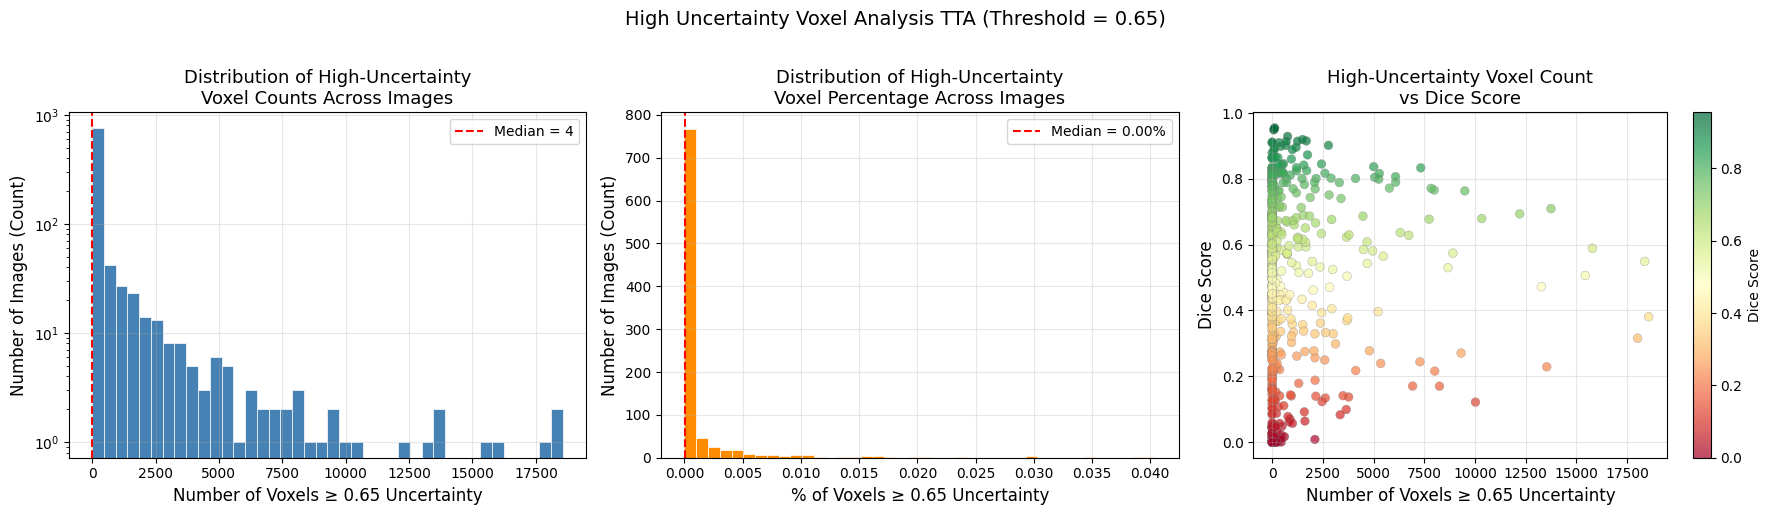


  Total images processed          : 940
  Images with ANY voxels ≥ 0.65   : 497
  Images with ZERO voxels ≥ 0.65  : 443
  Median high-unc voxel count     : 4
  Max high-unc voxel count        : 18559
  Mean % high-unc voxels          : 0.001%


In [ ]:
# import numpy as np
# import tqdm 
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# def process_uncertainty_map_averages(uncertainty_map, filename, predicted_label=None, bin_size=0.05, max_val=1.0):
#     """
#     Takes an uncertainty map, bins it, and returns statistics.
    
#     Parameters:
#     -----------
#     uncertainty_map : np.ndarray
#         The uncertainty map
#     filename : str
#         Name of the file
#     predicted_label : np.ndarray, optional
#         Binary mask of predicted pixels (predicted > 0). If provided, 
#         calculates uncertainty statistics for predicted vs non-predicted regions.
#     bin_size : float
#         Size of bins for histogram
#     max_val : float
#         Maximum value for histogram
    
#     Returns:
#     --------
#     tuple : (binned_df, summary_df)
#         - binned_df: DataFrame with histogram bins
#         - summary_df: DataFrame with aggregate statistics
#     """
#     values = uncertainty_map.flatten()
#     bin_edges = np.arange(0, max_val + bin_size, bin_size)
#     counts, edges = np.histogram(values, bins=bin_edges)
#     bin_labels = [f"{edges[i]:.2f}-{edges[i+1]:.2f}" for i in range(len(edges)-1)]    
    
#     binned_df = pd.DataFrame({
#         'bin': bin_labels,
#         'count': counts,
#         'filename': filename
#     })
    
#     # Calculate summary statistics
#     summary_stats = {
#         'filename': filename,
#         'average_uncertainty': float(np.mean(values)),
#         'average_uncertainty_above_0': float(np.mean(values[values > 0])) if np.any(values > 0) else np.nan,
#     }
    
#     # Add predicted/non-predicted statistics if mask is provided
#     if predicted_label is not None:
#         predicted_mask = predicted_label > 0
#         uncertainty_predicted = values[predicted_mask.flatten()]
#         uncertainty_non_predicted = values[~predicted_mask.flatten()]
        
#         summary_stats['average_uncertainty_predicted'] = float(np.mean(uncertainty_predicted)) if uncertainty_predicted.size > 0 else np.nan
#         summary_stats['average_uncertainty_non_predicted'] = float(np.mean(uncertainty_non_predicted)) if uncertainty_non_predicted.size > 0 else np.nan
#     else:
#         summary_stats['average_uncertainty_predicted'] = np.nan
#         summary_stats['average_uncertainty_non_predicted'] = np.nan
    
#     summary_df = pd.DataFrame([summary_stats])
    
#     return binned_df, summary_df

    
# # Usage - loop over your files
# dfs = []
# summary_dfs = []
# for filepath in tqdm.tqdm(file_names_in_true):  # Process first 10a files as an example
#     uncertainty_map = get_uncertainty_map(filepath.replace('.nii.gz', '_uncertainty_uncertainty.nii.gz'), UNCERTAINTY_MAPS_DIR)
#     predicted_map = get_predicted_label(filepath, PREDICTED_LABELS_DIR)
#     dice_for_case = get_dice_for_case(filepath, per_cases)
    
#     filename = os.path.basename(filepath)
#     binned_df, summary_df = process_uncertainty_map(uncertainty_map, filename, predicted_label=predicted_map)
#     # add the dice
#     summary_df['dice'] = dice_for_case
#     binned_df['dice'] = dice_for_case
#     dfs.append(binned_df)
#     summary_dfs.append(summary_df)

# combined_df = pd.concat(dfs, ignore_index=True)
# combined_summary_df = pd.concat(summary_dfs, ignore_index=True)


Text(0, 0.5, 'Dice Score')

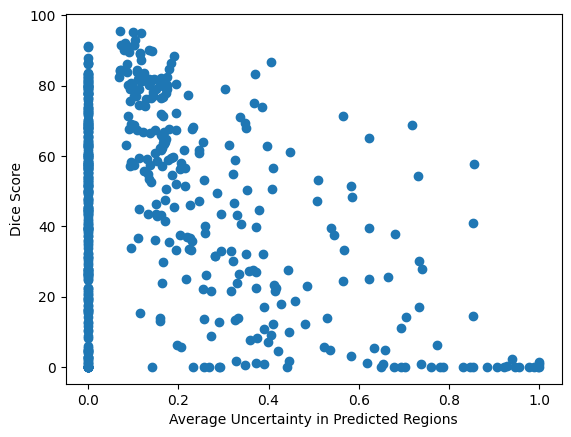

In [77]:
# plot hi stogram of the combined_summary_df
plt.plot(combined_summary_df['average_uncertainty_predicted'], combined_summary_df['dice'], 'o')
plt.xlabel('Average Uncertainty in Predicted Regions')
plt.ylabel('Dice Score')

In [72]:
combined_summary_df.columns

Index(['filename', 'average_uncertainty', 'average_uncertainty_above_0',
       'average_uncertainty_predicted', 'average_uncertainty_non_predicted',
       'dice'],
      dtype='object')

In [69]:
combined_summary_df

,filename,average_uncertainty,average_uncertainty_above_0,average_uncertainty_predicted,average_uncertainty_non_predicted,dice
0,fdg_8aa48809ea_04-16-2001-NA-PET-CT Ganzkoerpe...,3.623562e-05,0.000419,0.068423,2.128169e-05,82.466889
1,fdg_249c02c01c_03-06-2003-NA-PET-CT Ganzkoerpe...,8.568868e-05,0.001328,0.444418,6.447624e-05,9.875857
2,fdg_ae46202abb_02-28-2003-NA-PET-CT Ganzkoerpe...,4.858113e-06,0.000073,0.136393,3.548087e-06,NaN
3,psma_7fd33c03d8712a0b_2018-02-16.nii.gz,0.000000e+00,NaN,0.000000,0.000000e+00,57.709038
4,fdg_b4247b8ecd_05-27-2007-NA-PET-CT Ganzkoerpe...,9.865571e-07,0.000013,NaN,9.865571e-07,NaN
...,...,...,...,...,...,...
935,psma_ee0d631fa63961f2_2019-11-08.nii.gz,0.000000e+00,NaN,0.000000,0.000000e+00,45.106383
936,psma_7e25beff54698eb8_2021-02-06.nii.gz,0.000000e+00,NaN,0.000000,0.000000e+00,55.452942
937,fdg_e4712dc58c_02-12-1999-NA-PET-CT Ganzkoerpe...,1.312496e-05,0.000114,0.335285,7.327031e-06,26.490464
938,psma_209536ec8c0b1d5e_2019-11-04.nii.gz,0.000000e+00,NaN,0.000000,0.000000e+00,77.722772


In [55]:
# # combine all your dataframes first
combined_df.to_csv('binned_combined_df_train_tta.csv', index=False)
combined_summary_df.to_csv('summary_combined_df_train_tta.csv', index=False)

In [56]:
from datetime import time


combined_summary_df['dice'] = combined_summary_df['dice'] * 100

# save combined_df and combined_summary_df


In [57]:
time

datetime.time

<Figure size 1000x600 with 0 Axes>

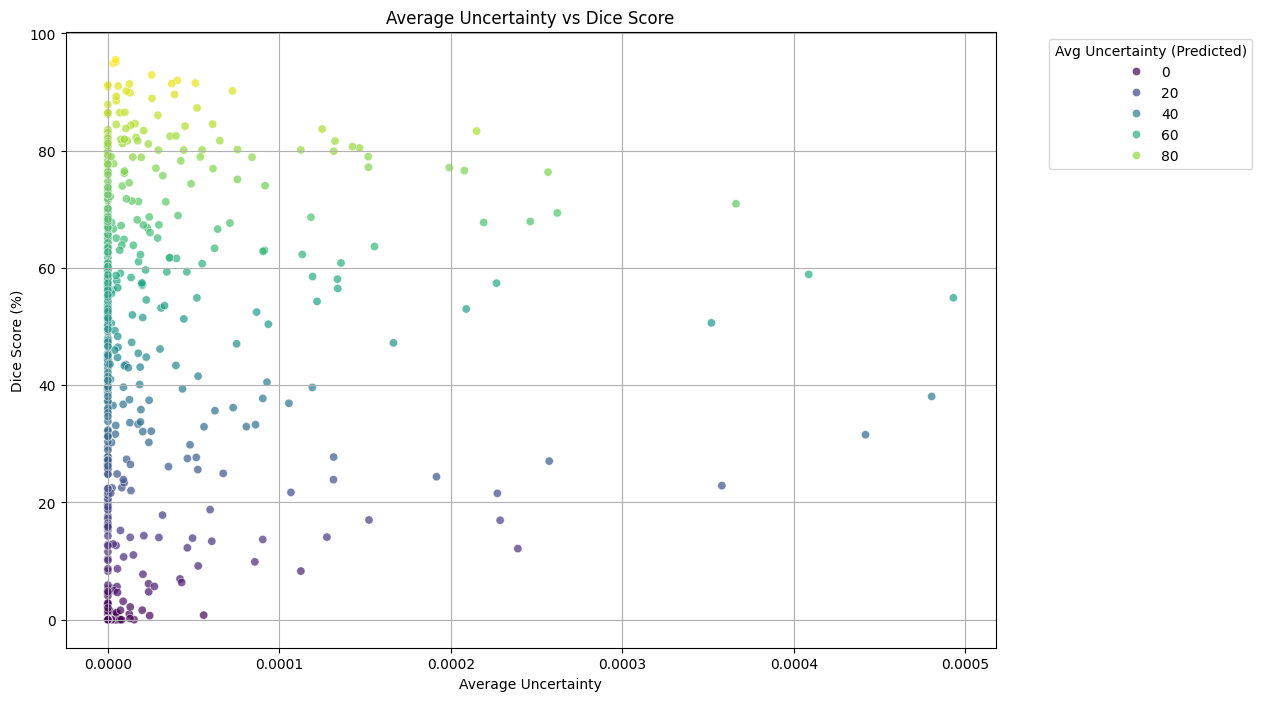

In [58]:
# do a histplot of the average uncertainty for predicted vs non-predicted regions
plt.figure(figsize=(10, 6))

# do bar plots for the average uncertainty, and for the average_uncertainty_above_0 and color them based on the average dice in that bin. Bins are based on uncertainty

# make bins on uncertainty from this,  like do it for every 0.05 bin, and then plot the average dice in that bin as a color. So x axis is uncertainty bin, y axis is average dice, and color is average uncertainty in that bin. Do this for both predicted and non-predicted regions.

def plot_uncertainty_vs_dice(combined_summary_df):
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=combined_summary_df, 
        x='average_uncertainty', 
        y='dice', 
        hue='dice', 
        palette='viridis', 
        sizes=(20, 200),
        alpha=0.7
    )
    plt.title('Average Uncertainty vs Dice Score')
    plt.xlabel('Average Uncertainty')
    plt.ylabel('Dice Score (%)')
    plt.legend(title='Avg Uncertainty (Predicted)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid()
    plt.show()

plot_uncertainty_vs_dice(combined_summary_df)

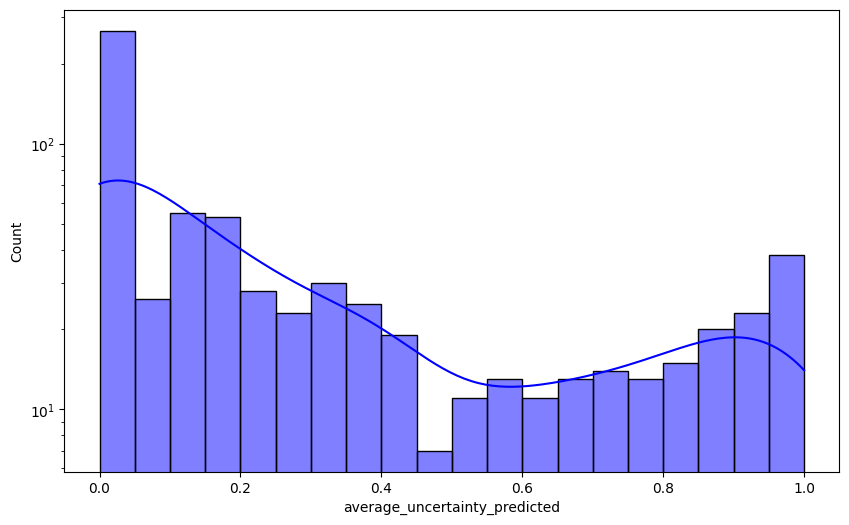

In [80]:
# do a histplot of the average uncertainty for predicted vs non-predicted regions
plt.figure(figsize=(10, 6))
sns.histplot(data=combined_summary_df, x='average_uncertainty_predicted', color='blue', label='Predicted Regions', kde=True, stat="count", bins=20)
plt.yscale('log')
# do the 

In [61]:
combined_summary_df

,filename,average_uncertainty,average_uncertainty_above_0,average_uncertainty_predicted,average_uncertainty_non_predicted,dice
0,fdg_8aa48809ea_04-16-2001-NA-PET-CT Ganzkoerpe...,3.623562e-05,0.000419,0.068423,2.128169e-05,82.466889
1,fdg_249c02c01c_03-06-2003-NA-PET-CT Ganzkoerpe...,8.568868e-05,0.001328,0.444418,6.447624e-05,9.875857
2,fdg_ae46202abb_02-28-2003-NA-PET-CT Ganzkoerpe...,4.858113e-06,0.000073,0.136393,3.548087e-06,NaN
3,psma_7fd33c03d8712a0b_2018-02-16.nii.gz,0.000000e+00,NaN,0.000000,0.000000e+00,57.709038
4,fdg_b4247b8ecd_05-27-2007-NA-PET-CT Ganzkoerpe...,9.865571e-07,0.000013,NaN,9.865571e-07,NaN
...,...,...,...,...,...,...
935,psma_ee0d631fa63961f2_2019-11-08.nii.gz,0.000000e+00,NaN,0.000000,0.000000e+00,45.106383
936,psma_7e25beff54698eb8_2021-02-06.nii.gz,0.000000e+00,NaN,0.000000,0.000000e+00,55.452942
937,fdg_e4712dc58c_02-12-1999-NA-PET-CT Ganzkoerpe...,1.312496e-05,0.000114,0.335285,7.327031e-06,26.490464
938,psma_209536ec8c0b1d5e_2019-11-04.nii.gz,0.000000e+00,NaN,0.000000,0.000000e+00,77.722772


In [62]:
# get a cumulative count for each bin as well 
cumilative_df = combined_df.groupby('bin')['count'].sum().reset_index()
cumilative_df

,bin,count
0,0.00-0.05,38775123923
1,0.05-0.10,230838
2,0.10-0.15,111861
3,0.15-0.20,74747
4,0.20-0.25,57746
5,0.25-0.30,47574
6,0.30-0.35,42368
7,0.35-0.40,39420
8,0.40-0.45,38441
9,0.45-0.50,39147


In [63]:
# combine all your dataframes first
combined_df = pd.concat(dfs, ignore_index=True)


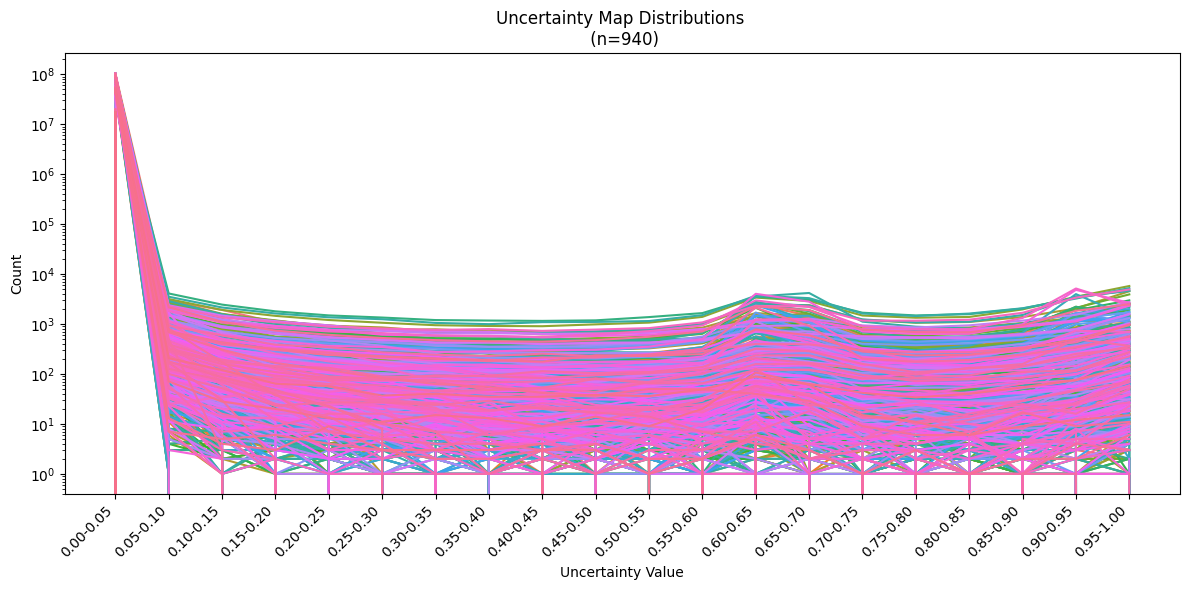

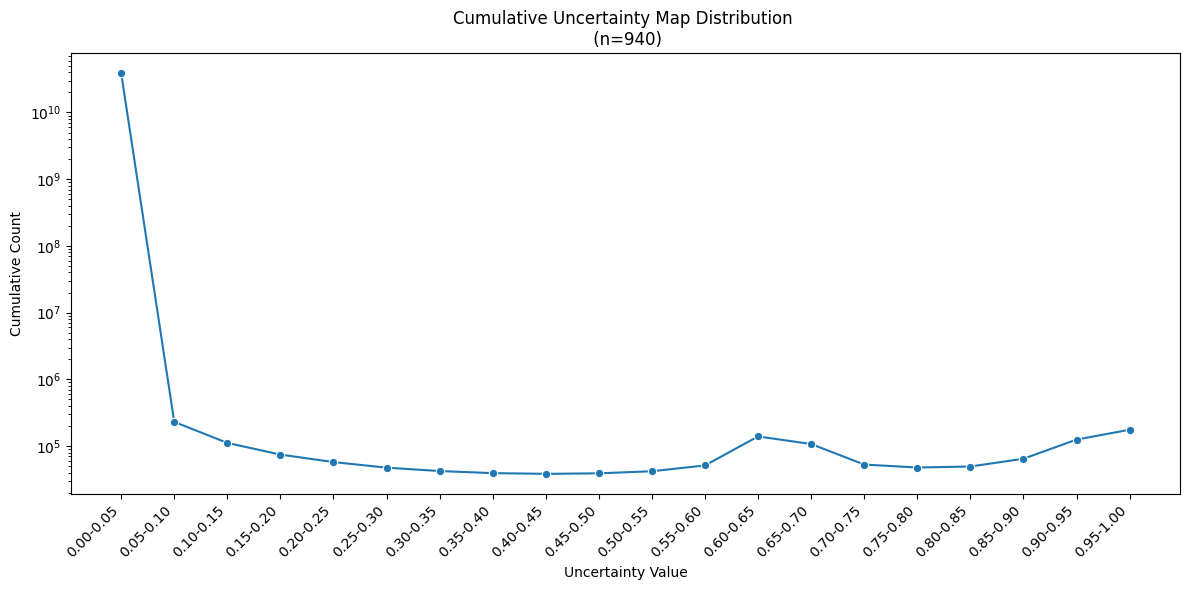

In [64]:
# combine all your dataframes first
# combined_df = pd.concat(dfs, ignore_index=True)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=combined_df,
    x='bin',
    y='count',
    hue='filename', 
    legend=None
)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Uncertainty Value')
plt.ylabel('Count')
plt.yscale('log')
plt.title('Uncertainty Map Distributions \n (n={})'.format(len(files_with_prefix)))
plt.tight_layout()
plt.show()

# also plot the cumulative count
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=cumilative_df,
    x='bin',
    y='count', 
    marker='o'
)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Uncertainty Value')
plt.ylabel('Cumulative Count')
plt.yscale('log')
plt.title('Cumulative Uncertainty Map Distribution \n (n={})'.format(len(files_with_prefix)))
plt.tight_layout()

In [ ]:
# do the same but for the average, median, 

c:\Users\BhattacharyaLab\anaconda3\envs\monai310\lib\site-packages\matplotlib\axes\_axes.py:7104: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
c:\Users\BhattacharyaLab\anaconda3\envs\monai310\lib\site-packages\matplotlib\axes\_axes.py:7105: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

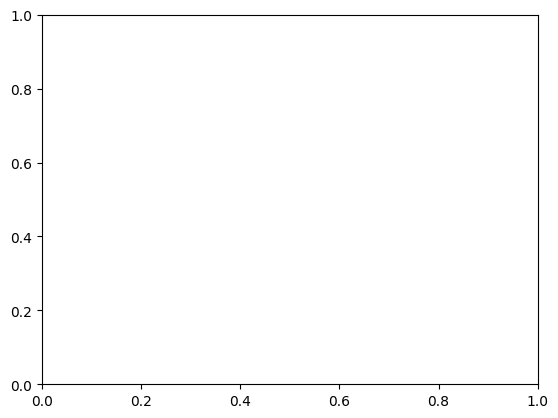

In [45]:
# plot a histogram of the uncertainty_map_values
import matplotlib.pyplot as plt
# plt.hist(uncertainty_at_predicted, bins=50)
# plt.xlabel('Uncertainty')
# plt.ylabel('Frequency')

uuncertainty_map_values = uncertainty_map.flatten()
plt.hist(uuncertainty_map_values, bins=50)
# plot it in log scale
plt.yscale('log')

In [10]:
# show heatmap of uncertainty map
import matplotlib.pyplot as plt

# Use MEAN instead of MAX for uncertainty (more representative)
z_project_unc = np.mean(uncertainty_map, axis=2)  # changed from np.max
z_project = np.max(true_label, axis=2)
z_project_pred = np.max(predicted_label, axis=2)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(z_project, cmap='gray')
ax[0].set_title('Z-projection of True Label')

ax[1].imshow(z_project_pred, cmap='gray')
ax[1].set_title('Z-projection of Predicted Label')

im_unc = ax[2].imshow(
    z_project_unc,
    cmap='hot',
    interpolation='nearest',
    vmin=0,
    vmax=np.percentile(z_project_unc, 99)  # ignore extreme outliers
)
ax[2].set_title('Z-projection of Uncertainty Map (Mean)')
fig.colorbar(im_unc, ax=ax[2], fraction=0.046, pad=0.04, label='Uncertainty Value')

for axis in ax:
    axis.set_xlabel('X-axis')
    axis.set_ylabel('Y-axis')

case_name = file_names_in_true[0].replace('.nii.gz', '')
plt.suptitle(
    f"{case_name}\nDice: {np.round(file_dice, 4)}      Mean Uncertainty of Predicted Voxels: {np.round(np.mean(mean_uncertainty_at_predicted), 4)}"
)
plt.tight_layout()
plt.show()

NameError: name 'true_label' is not defined

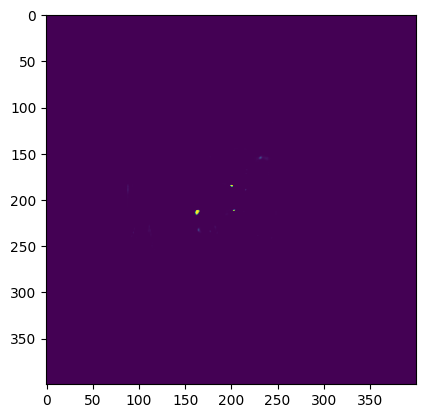

In [11]:
z_project_unc = np.max(uncertainty_map, axis=2)
plt.imshow(z_project_unc)

In [12]:
import os
import json
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)


def extract_case_metrics(case):
    metrics = case.get("metrics", {})
    dice_value = np.nan

    if isinstance(metrics, dict):
        if "1" in metrics and isinstance(metrics["1"], dict) and "Dice" in metrics["1"]:
            dice_value = metrics["1"]["Dice"]
        else:
            for value in metrics.values():
                if isinstance(value, dict) and "Dice" in value:
                    dice_value = value["Dice"]
                    break

    return {
        "dice": float(dice_value) if np.isfinite(dice_value) else np.nan,
    }


def get_case_record(case):
    prediction_name = Path(case.get("prediction_file", "")).name
    if not prediction_name:
        return None

    case_id = prediction_name.replace(".nii.gz", "")
    uncertainty_name = f"{case_id}_total_uncertainty.nii.gz"

    uncertainty_path = Path(UNCERTAINTY_MAPS_DIR) / uncertainty_name
    predicted_path = Path(PREDICTED_LABELS_DIR) / prediction_name
    true_path = Path(TRUE_LABELS_DIR) / prediction_name

    if not uncertainty_path.exists() or not predicted_path.exists():
        return None

    uncertainty_map = nib.load(str(uncertainty_path)).get_fdata()
    predicted_label = nib.load(str(predicted_path)).get_fdata()

    predicted_mask = predicted_label > 0
    uncertainty_pred = uncertainty_map[predicted_mask]

    has_ground_truth = true_path.exists()
    gt_positive_fraction = np.nan
    
    if has_ground_truth:
        true_label = nib.load(str(true_path)).get_fdata()
        gt_positive_fraction = float(np.mean(true_label >= 1))

    metrics = extract_case_metrics(case)

    return {
        "case_id": case_id,
        "prediction_file": prediction_name,
        "uncertainty_file": uncertainty_name,
        "has_ground_truth": bool(has_ground_truth),
        "dice": metrics["dice"] if has_ground_truth else np.nan,
        "mean_uncertainty_predicted_voxels": float(np.mean(uncertainty_pred)) if uncertainty_pred.size else np.nan,
        "median_uncertainty_predicted_voxels": float(np.median(uncertainty_pred)) if uncertainty_pred.size else np.nan,
        "mean_uncertainty_image": float(np.mean(uncertainty_map)),
        "std_uncertainty_image": float(np.std(uncertainty_map)),
        "predicted_voxel_count": int(np.count_nonzero(predicted_mask)),
        "predicted_voxel_fraction": float(np.mean(predicted_mask)),
        "uncertainty_fraction_above_0.001": float(np.mean(uncertainty_map > 0.001)),
        "gt_positive_fraction": gt_positive_fraction,
    }

In [11]:
import tqdm
with open(SUMMARY_JSON_DIR, "r") as f:
    summary_json = json.load(f)

per_cases = summary_json.get("metric_per_case", [])

valid_case_records = []
for case in tqdm.tqdm(per_cases):
    rec = get_case_record(case)
    if rec is not None:
        valid_case_records.append(rec)
    else: 
        print(f"Warning: Case {case.get('prediction_file', 'unknown')} is missing required files and will be skipped.")



100%|██████████| 247/247 [00:00<00:00, 27811.89it/s]

In [162]:
# convert list of dicts to dataframe and sort by has_ground_truth and dice
# make df long not wide

list_of_dfs = []
for rec in valid_case_records:
    temp_df = pd.DataFrame([rec])
    list_of_dfs.append(temp_df)
    
big_df = pd.concat(list_of_dfs, ignore_index=True)


In [182]:
# count how many are 0 

df_without_gt = big_df.loc[big_df['gt_positive_fraction'] == 0]
df_with_gt = big_df[big_df["gt_positive_fraction"] > 0].copy()
# set had_ground_truth to False for df_without_gt and True for df_with_gt
df_without_gt.loc[df_without_gt.index, 'has_ground_truth'] = False
df_with_gt.loc[df_with_gt.index, 'has_ground_truth'] = True

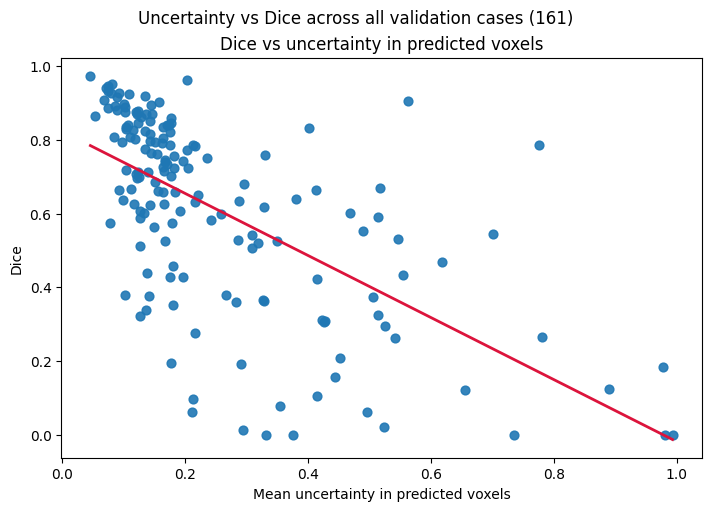

In [227]:
fig, axes = plt.subplots(1, 1, figsize=(7, 5), constrained_layout=True)

DF_PLOT = df_with_gt


s1 = axes.scatter(
    DF_PLOT["mean_uncertainty_predicted_voxels"],
    DF_PLOT["dice"],
    alpha=0.9,
    s=40,
)
axes.set_title("Dice vs uncertainty in predicted voxels")
axes.set_xlabel("Mean uncertainty in predicted voxels")
axes.set_ylabel("Dice")

x = axes.collections[0].get_offsets()[:, 0]
y = axes.collections[0].get_offsets()[:, 1]
valid = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(valid) >= 2 and np.unique(x[valid]).size > 1:
    slope, intercept = np.polyfit(x[valid], y[valid], 1)
    xx = np.linspace(x[valid].min(), x[valid].max(), 100)
    axes.plot(xx, slope * xx + intercept, color="crimson", linewidth=2)

plt.suptitle(f"Uncertainty vs Dice across all validation cases ({len(DF_PLOT)})")
plt.show()



In [196]:
DF_PLOT.columns

Index(['case_id', 'prediction_file', 'uncertainty_file', 'has_ground_truth',
       'dice', 'mean_uncertainty_predicted_voxels',
       'median_uncertainty_predicted_voxels', 'mean_uncertainty_image',
       'std_uncertainty_image', 'predicted_voxel_count',
       'predicted_voxel_fraction', 'uncertainty_fraction_above_0.001',
       'gt_positive_fraction'],
      dtype='object')

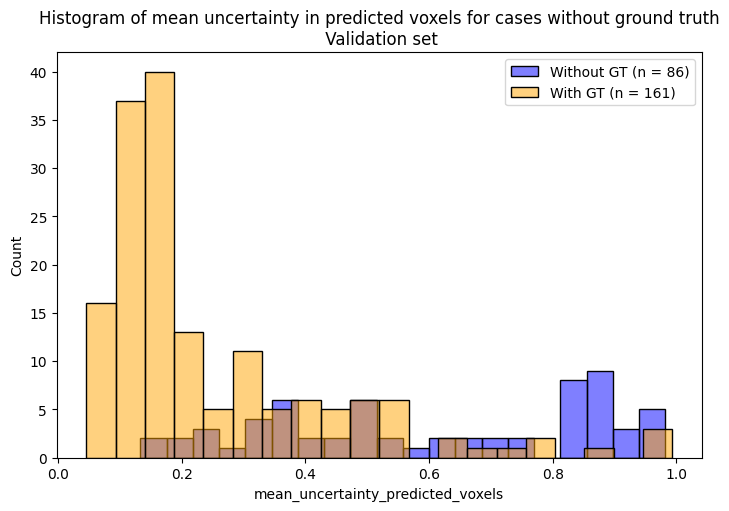

In [207]:
fig, axes = plt.subplots(1, 1, figsize=(7, 5), constrained_layout=True)

DF_PLOT = df_without_gt

# do a histogram of the mean uncertainty in predicted voxels for cases without ground truth
import seaborn as sns
sns.histplot(df_without_gt["mean_uncertainty_predicted_voxels"], bins=20, ax=axes, label = f"Without GT (n = {len(df_without_gt)})", color="blue", alpha=0.5)
sns.histplot(df_with_gt["mean_uncertainty_predicted_voxels"], bins=20, ax=axes, label = f"With GT (n = {len(df_with_gt)})", color="orange", alpha=0.5)
axes.set_title("Histogram of mean uncertainty in predicted voxels for cases without ground truth\n Validation set")
axes.legend()



In [218]:
np.sum(df_without_gt['mean_uncertainty_predicted_voxels'] > 0.8)

np.int64(25)

Text(0.5, 1.0, 'Histogram of Dice scores for cases with ground truth\n Validation set (n = 161)')

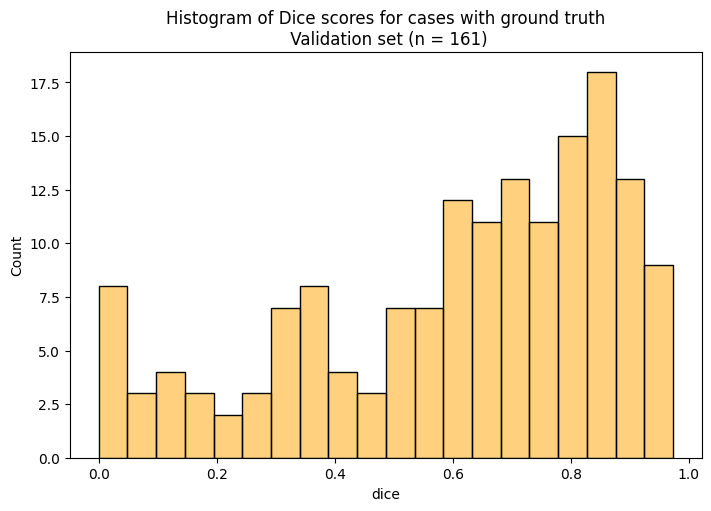

In [225]:
# with the gt have a histogram of the dice
fig, axes = plt.subplots(1, 1, figsize=(7, 5), constrained_layout=True)
sns.histplot(df_with_gt["dice"], bins=20, ax=axes, label = f"With GT (n = {len(df_with_gt)})", color="orange", alpha=0.5)
axes.set_title(f"Histogram of Dice scores for cases with ground truth\n Validation set (n = {len(df_with_gt)})")


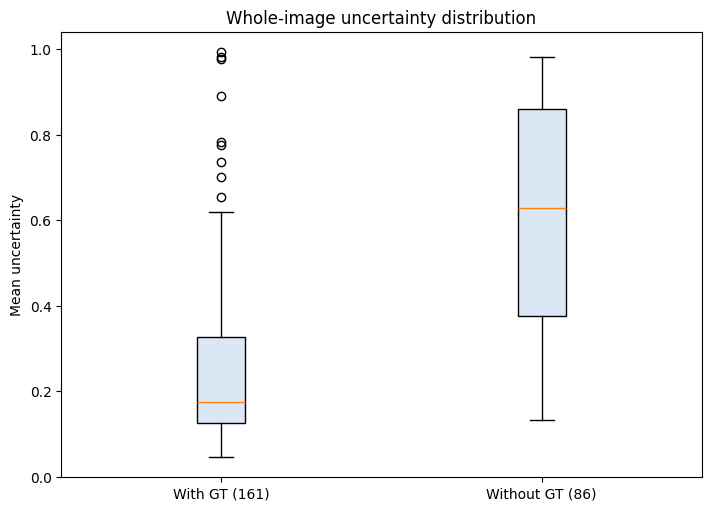

In [223]:
fig, axes = plt.subplots(1, 1, figsize=(7, 5), constrained_layout=True)


box_data = []
labels = []
if len(df_with_gt) > 0:
    box_data.append(df_with_gt["mean_uncertainty_predicted_voxels"].dropna())
    labels.append(f"With GT ({len(df_with_gt)})")
box_data.append(df_without_gt["mean_uncertainty_predicted_voxels"].dropna())
labels.append(f"Without GT ({len(df_without_gt)})")

axes.boxplot(box_data, tick_labels=labels, patch_artist=True, boxprops={"facecolor": "#dce7f5"})
axes.set_title("Whole-image uncertainty distribution")
axes.set_ylabel("Mean uncertainty")

plt.show()


In [ ]:
feature_columns = [
    "mean_uncertainty_predicted_voxels",
    "mean_uncertainty_image",
    "predicted_voxel_fraction",
    "predicted_voxel_count",
    "std_uncertainty_image",
]

regression_df = df_with_gt.dropna(subset=feature_columns + ["dice"]).copy()

if len(regression_df) >= 5:
    X = regression_df[feature_columns].to_numpy(dtype=float)
    y = regression_df["dice"].to_numpy(dtype=float)

    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)
    X_std[X_std == 0] = 1.0
    Xz = (X - X_mean) / X_std

    design = np.c_[np.ones(len(Xz)), Xz]
    coefs = np.linalg.lstsq(design, y, rcond=None)[0]
    pred = design @ coefs

    tss = float(np.sum((y - np.mean(y)) ** 2))
    rss = float(np.sum((y - pred) ** 2))
    r2 = 1 - rss / tss if tss > 0 else np.nan

    coef_df = pd.DataFrame({
        "feature": ["intercept"] + feature_columns,
        "standardized_coefficient": coefs,
    }).sort_values("standardized_coefficient", key=lambda s: s.abs(), ascending=False)

    display(coef_df)
    print(f"Linear regression R^2: {r2:.3f}")
else:
    print("Not enough GT cases for regression (need at least 5).")

,feature,standardized_coefficient
0,intercept,0.615896
2,mean_uncertainty_image,-0.225498
3,predicted_voxel_fraction,0.205314
1,mean_uncertainty_predicted_voxels,-0.144254
5,std_uncertainty_image,0.054368
4,predicted_voxel_count,0.013548


Linear regression R^2: 0.496


In [129]:
summary_cols = [
    "mean_uncertainty_predicted_voxels",
    "mean_uncertainty_image",
    "predicted_voxel_fraction",
    "predicted_voxel_count",
]

print("Summary by has_ground_truth")
display(df.groupby("has_ground_truth")[summary_cols].agg(["count", "mean", "std"]))

print("Top uncertain GT cases")
if len(df_with_gt) > 0:
    display(df_with_gt.sort_values("mean_uncertainty_predicted_voxels", ascending=False).head(10))
else:
    print("None")

print("Top uncertain no-GT cases")
if len(df_without_gt) > 0:
    display(df_without_gt.sort_values("mean_uncertainty_predicted_voxels", ascending=False).head(10))
else:
    print("None")

# Optional: persist table for downstream analysis
# df.to_csv(os.path.join(SAVE_DIR, "uncertainty_case_summary_100.csv"), index=False)

Summary by has_ground_truth


mean_uncertainty_predicted_voxels                      \
                                             count      mean       std   
has_ground_truth                                                         
True                                            92  0.352868  0.279939   

                 mean_uncertainty_image                      \
                                  count      mean       std   
has_ground_truth                                              
True                                100  0.000125  0.000316   

                 predicted_voxel_fraction                     \
                                    count     mean       std   
has_ground_truth                                               
True                                  100  0.00037  0.000977   

                 predicted_voxel_count                         
                                 count     mean           std  
has_ground_truth                                               
True                               100  7450.94  14795.710202

Top uncertain GT cases


,case_id,prediction_file,uncertainty_file,has_ground_truth,dice,mean_uncertainty_predicted_voxels,median_uncertainty_predicted_voxels,mean_uncertainty_image,std_uncertainty_image,predicted_voxel_count,predicted_voxel_fraction,uncertainty_fraction_above_0.001,gt_positive_fraction
3,fdg_11afab3485_05-25-2003-NA-PET-CT Ganzkoerpe...,fdg_11afab3485_05-25-2003-NA-PET-CT Ganzkoerpe...,fdg_11afab3485_05-25-2003-NA-PET-CT Ganzkoerpe...,True,0.000000,0.993432,0.993432,0.000003,0.001313,2,4.401408e-08,0.000011,4.555458e-06
1,psma_d7c4cf294221ea45_2017-03-03,psma_d7c4cf294221ea45_2017-03-03.nii.gz,psma_d7c4cf294221ea45_2017-03-03_total_uncerta...,True,0.000000,0.980627,0.980279,0.000002,0.001273,4,2.506266e-07,0.000004,3.696742e-06
7,fdg_7785c10e91_12-15-2006-NA-PET-CT Ganzkoerpe...,fdg_7785c10e91_12-15-2006-NA-PET-CT Ganzkoerpe...,fdg_7785c10e91_12-15-2006-NA-PET-CT Ganzkoerpe...,True,0.265107,0.781666,0.912116,0.000010,0.002739,175,1.798931e-06,0.000033,3.474507e-06
2,fdg_d7ca3d4aaa_07-05-2003-NA-PET-CT Ganzkoerpe...,fdg_d7ca3d4aaa_07-05-2003-NA-PET-CT Ganzkoerpe...,fdg_d7ca3d4aaa_07-05-2003-NA-PET-CT Ganzkoerpe...,True,0.000000,0.734732,0.899858,0.000003,0.001546,149,1.740654e-06,0.000012,8.995327e-07
23,psma_43327d1d34bc5300_2015-09-06,psma_43327d1d34bc5300_2015-09-06.nii.gz,psma_43327d1d34bc5300_2015-09-06_total_uncerta...,True,0.545455,0.700516,0.652266,0.000006,0.002025,4,8.589294e-07,0.000019,1.503127e-06
9,psma_7ee9adc7b31f780e_2018-06-29,psma_7ee9adc7b31f780e_2018-06-29.nii.gz,psma_7ee9adc7b31f780e_2018-06-29_total_uncerta...,True,0.295964,0.525211,0.549942,0.000004,0.001664,35,2.139364e-06,0.000009,1.149144e-05
12,psma_8fcd87e9f20d00b0_2018-10-13,psma_8fcd87e9f20d00b0_2018-10-13.nii.gz,psma_8fcd87e9f20d00b0_2018-10-13_total_uncerta...,True,0.324655,0.514393,0.674499,0.000016,0.003482,274,1.589699e-05,0.000038,5.987479e-05
26,psma_d7c4cf294221ea45_2019-05-10,psma_d7c4cf294221ea45_2019-05-10.nii.gz,psma_d7c4cf294221ea45_2019-05-10_total_uncerta...,True,0.591549,0.514060,0.610031,0.000004,0.001694,31,1.952141e-06,0.000028,2.518892e-06
14,fdg_b7c1533a39_02-12-2005-NA-PET-CT Ganzkoerpe...,fdg_b7c1533a39_02-12-2005-NA-PET-CT Ganzkoerpe...,fdg_b7c1533a39_02-12-2005-NA-PET-CT Ganzkoerpe...,True,0.374911,0.504987,0.720061,0.000230,0.013479,6410,1.228911e-04,0.000429,3.903183e-04
10,psma_b3f377bd2b873391_2021-12-25,psma_b3f377bd2b873391_2021-12-25.nii.gz,psma_b3f377bd2b873391_2021-12-25_total_uncerta...,True,0.312139,0.423426,0.158009,0.000004,0.001677,39,2.128821e-06,0.000018,7.314410e-06


Top uncertain no-GT cases
None
